In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns
from vta.utils import CCF
import pickle

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import plotly.graph_objects as go

from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline

%matplotlib inline
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", font_scale=0.8, rc=custom_params)
%config InlineBackend.figure_format='retina'

%load_ext autoreload
%autoreload 2

In [2]:
# read in csv file containing cell coordinates
df_ccf = pd.read_csv("/results/FINAL_manual_proofread_ccf_37brains.csv")
ccf = CCF()

In [3]:
# Filter out thalamic cells given they might be a mixture of TH and CTX projecting neurons
print(df_ccf.shape)
df_ccf = df_ccf[df_ccf["injection_region"] != "TH"]
print(df_ccf.shape)

(15876, 7)
(13665, 7)


In [4]:
# rename x, y, z columns to their corresponding ccf dimentions RC, DV, ML
df_ccf = df_ccf.rename(columns={"x": "ML", "y": "DV", "z": "RC"})

# using an approximate midline value based on the barplot
approx_midline = 230
df_ccf["ipsi"] = df_ccf["ML"] > 230
display(df_ccf.head(5))

,brain,channel,injection_region,ML,DV,RC,batch,ipsi
0,746046,561,CTX,261.107788,160.238174,426.496399,final,True
1,746046,561,CTX,260.630951,162.411804,426.451996,final,True
2,746046,561,CTX,260.420593,163.047180,426.273346,final,True
3,746046,561,CTX,258.255768,168.814880,424.967255,final,True
4,746046,561,CTX,254.746948,170.891434,423.269836,final,True


In [5]:
# check the range of RC, DV, ML values in df
print(df_ccf["RC"].min(), df_ccf["RC"].max())
print(df_ccf["DV"].min(), df_ccf["DV"].max())
print(df_ccf["ML"].min(), df_ccf["ML"].max())

378.14114379882807 444.62493896484375
138.59121704101562 284.2338256835937
130.2820587158203 313.3256530761719


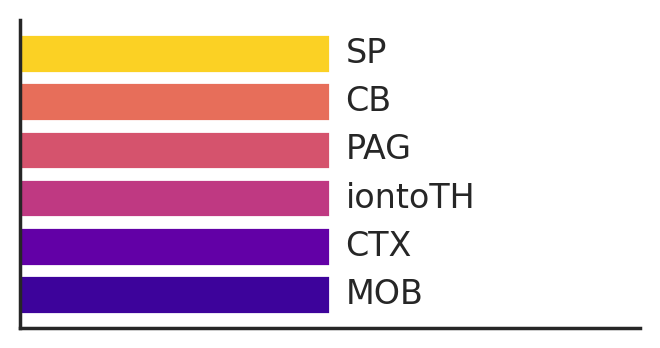

In [6]:
# define color codes for each ROI
cols_hex = ["#3D039B", "#6200A6", "#BF3982", "#D5536D", "#E76E5A", "#FBD124"]
region_col_map = dict(zip(["MOB", "CTX", "iontoTH", "PAG", "CB", "SP"], cols_hex))

fig, ax = plt.subplots(figsize=(4, 2))
for i, (region, color) in enumerate(region_col_map.items()):
    ax.barh(i, 1, color=color)
    ax.text(1.05, i, region, va='center', fontsize=12)
ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(0, 2)
plt.show()

In [7]:
#convert df_ccf to microns by multiplying the values of RC, ML and DV columns by ccf.resolution
df_ccf[['RC', 'ML', 'DV']] = df_ccf[['RC', 'ML', 'DV']] * ccf.resolution

In [8]:
# Split data by hemisphere and define region order
df_ipsi = df_ccf[df_ccf["ipsi"] == True].copy()
df_contra = df_ccf[df_ccf["ipsi"] == False].copy()
order = ["MOB", "CTX", "iontoTH", "PAG", "CB", "SP"]

print(f"Data split: {len(df_ipsi)} ipsilateral, {len(df_contra)} contralateral cells")

Data split: 8565 ipsilateral, 5100 contralateral cells


In [9]:
display(df_ccf["injection_region"].value_counts().to_frame().sort_values(by="injection_region"))
print("Ipsilateral")
display(df_ipsi["injection_region"].value_counts().to_frame().sort_values(by="injection_region"))
print("Contralateral")
display(df_contra["injection_region"].value_counts().to_frame().sort_values(by="injection_region"))

,count
injection_region,
CB,3829
CTX,2714
MOB,928
PAG,1546
SP,4321
iontoTH,327


Ipsilateral


,count
injection_region,
CB,2087
CTX,2319
MOB,837
PAG,990
SP,2120
iontoTH,212


Contralateral


,count
injection_region,
CB,1742
CTX,395
MOB,91
PAG,556
SP,2201
iontoTH,115


In [10]:
# Step 1: Extract the relevant data
coordinates = df_ipsi[['RC', 'DV', 'ML']].values
projection_regions = df_ipsi['injection_region']

# Step 2: Perform PCA
pca = PCA(n_components=3)
pca_result = pca.fit_transform(coordinates)

# Explained variance by each principal component
explained_variance = pca.explained_variance_ratio_
print("Explained variance by each principal component:", explained_variance)

# Step 3: Perform LDA on the PCA result
lda = LinearDiscriminantAnalysis(n_components=1)
lda_result = lda.fit_transform(pca_result, projection_regions)

# LDA separation statistic: ratio of between-class to within-class variance
mean_total = np.mean(lda_result)
group_means = []
group_counts = []
within_var = 0
for region in np.unique(projection_regions):
    group = lda_result[np.array(projection_regions) == region]
    group_means.append(np.mean(group))
    group_counts.append(len(group))
    within_var += np.sum((group - np.mean(group))**2)
between_var = np.sum([n * (m - mean_total)**2 for m, n in zip(group_means, group_counts)])
fisher_criterion = between_var / within_var if within_var > 0 else np.nan
print(f"LDA separation statistic (Fisher's criterion): {fisher_criterion:.3f}")

# Step 4: Get the primary axis of variation
primary_axis_vector = lda.scalings_[:, 0]  # First linear discriminant
primary_axis_vector = primary_axis_vector / np.linalg.norm(primary_axis_vector)
print("Primary axis of variation (in PCA space):", primary_axis_vector)

# Transform back to the original coordinate space
primary_axis_in_original_space = np.dot(pca.components_.T, primary_axis_vector)
primary_axis_in_original_space = primary_axis_in_original_space / np.linalg.norm(primary_axis_in_original_space)
print("Primary axis of variation (in original space):", primary_axis_in_original_space)

# Step 5: Project coordinates onto the primary axis
projected_values = np.dot(coordinates, primary_axis_in_original_space)
df_proj = pd.DataFrame({
    'projected': projected_values,
    'region': projection_regions
})

# Step 6: Test normality for each group (safe for small n)
from scipy.stats import shapiro

normality_results = {}
region_levels = [r for r in order if r in df_proj["region"].unique()]
groups = [df_proj[df_proj["region"] == region]["projected"].values for region in region_levels]

for region, g in zip(region_levels, groups):
    if len(g) < 3:
        # Shapiro requires at least 3 observations
        normality_results[region] = 0.0
        print(f"Shapiro-Wilk test for {region}: skipped (n < 3), treated as non-normal")
    else:
        stat, p = shapiro(g)
        normality_results[region] = p
        print(f"Shapiro-Wilk test for {region}: p = {p:.3f}")

# Step 7: If all p > 0.05, use ANOVA; else, use Kruskal-Wallis
all_normal = all(p > 0.05 for p in normality_results.values())

if all_normal:
    from scipy.stats import f_oneway
    omnibus_stat, p_value = f_oneway(*groups)
    omnibus_method = "anova"
    print(f"\nANOVA: F = {omnibus_stat:.3f}, p = {p_value:.3e}")
else:
    from scipy.stats import kruskal
    omnibus_stat, p_value = kruskal(*groups)
    omnibus_method = "kruskal"
    print(f"\nKruskal-Wallis: H = {omnibus_stat:.3f}, p = {p_value:.3e}")

Explained variance by each principal component: [0.784764   0.16659326 0.04864274]
LDA separation statistic (Fisher's criterion): 0.662
Primary axis of variation (in PCA space): [-0.96321486  0.24459774  0.11130624]
Primary axis of variation (in original space): [ 0.60743297 -0.77078061 -0.19215212]
Shapiro-Wilk test for MOB: p = 0.004
Shapiro-Wilk test for CTX: p = 0.000
Shapiro-Wilk test for iontoTH: p = 0.001
Shapiro-Wilk test for PAG: p = 0.000
Shapiro-Wilk test for CB: p = 0.000
Shapiro-Wilk test for SP: p = 0.000

Kruskal-Wallis: H = 3615.861, p = 0.000e+00


In [11]:
# Effect size helper for Kruskal-Wallis (epsilon squared)
def epsilon_squared(H, n, k):
    return round((H - k + 1) / (n - k), 3)

n = len(df_proj)
k = len(region_levels)

if omnibus_method == "kruskal":
    h_stat = omnibus_stat
    print(f"Epsilon squared effect size: {epsilon_squared(h_stat, n, k):.3f}")
else:
    print("Omnibus method is ANOVA; skipping Kruskal epsilon-squared.")

# Bootstrap confidence interval for epsilon squared (Kruskal only)
def bootstrap_epsilon_squared(groups, n_boot=1000, random_state=42):
    np.random.seed(random_state)
    n = sum(len(g) for g in groups)
    k = len(groups)
    boot_stats = []
    for _ in range(n_boot):
        resampled = [np.random.choice(g, size=len(g), replace=True) for g in groups]
        all_data = np.concatenate(resampled)
        ranks = stats.rankdata(all_data)
        group_ranks = []
        start = 0
        for g in resampled:
            group_ranks.append(ranks[start:start+len(g)])
            start += len(g)
        mean_ranks = [r.mean() for r in group_ranks]
        H = (12 / (n * (n + 1))) * sum(len(g) * (mr ** 2) for g, mr in zip(resampled, mean_ranks)) - 3 * (n + 1)
        eps2 = (H - k + 1) / (n - k)
        boot_stats.append(eps2)
    ci_lower, ci_upper = np.percentile(boot_stats, [2.5, 97.5])
    return np.mean(boot_stats), ci_lower, ci_upper

def permutation_test(groups, n_perm=1000, random_state=42):
    np.random.seed(random_state)
    all_data = np.concatenate(groups)
    observed_H, _ = stats.kruskal(*groups)
    sizes = [len(g) for g in groups]
    perm_stats = []

    for _ in range(n_perm):
        shuffled = np.random.permutation(all_data)
        perm_groups = []
        start = 0
        for sz in sizes:
            perm_groups.append(shuffled[start:start+sz])
            start += sz
        H, _ = stats.kruskal(*perm_groups)
        perm_stats.append(H)

    p_perm = np.mean([h >= observed_H for h in perm_stats])
    return observed_H, p_perm

if omnibus_method == "kruskal":
    groups = [df_proj[df_proj['region'] == region]['projected'].values for region in region_levels]
    eps2_mean, eps2_ci_lower, eps2_ci_upper = bootstrap_epsilon_squared(groups)
    print(f"Bootstrap epsilon squared: mean={eps2_mean:.3f}, 95% CI=({eps2_ci_lower:.3f}, {eps2_ci_upper:.3f})")

    H_perm, p_perm = permutation_test(groups)
    print(f"Permutation Kruskal-Wallis: H={H_perm:.3f}, permuted p={p_perm:.4f}")

    # Pairwise Mann-Whitney U tests with Bonferroni correction
    from itertools import combinations
    from scipy.stats import mannwhitneyu

    results = []
    for r1, r2 in combinations(region_levels, 2):
        group1 = df_proj[df_proj['region'] == r1]['projected']
        group2 = df_proj[df_proj['region'] == r2]['projected']
        stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
        results.append({'pair': f"{r1} vs {r2}", 'p': p})

    bonf_p = [min(r['p'] * len(results), 1.0) for r in results]
    for r, p_corr in zip(results, bonf_p):
        print(f"{r['pair']}: corrected p = {p_corr:.3e}")

    pd.DataFrame(results).to_csv("/results/pairwise_posthoc_results.csv", index=False)
else:
    print("Skipping Kruskal bootstrap/permutation/posthoc because ANOVA was selected.")

Epsilon squared effect size: 0.422
Bootstrap epsilon squared: mean=0.422, 95% CI=(0.409, 0.435)
Permutation Kruskal-Wallis: H=3615.861, permuted p=0.0000
MOB vs CTX: corrected p = 2.019e-05
MOB vs iontoTH: corrected p = 1.000e+00
MOB vs PAG: corrected p = 8.384e-27
MOB vs CB: corrected p = 2.403e-76
MOB vs SP: corrected p = 0.000e+00
CTX vs iontoTH: corrected p = 2.340e-04
CTX vs PAG: corrected p = 2.897e-18
CTX vs CB: corrected p = 5.036e-95
CTX vs SP: corrected p = 0.000e+00
iontoTH vs PAG: corrected p = 6.720e-15
iontoTH vs CB: corrected p = 6.319e-30
iontoTH vs SP: corrected p = 1.941e-113
PAG vs CB: corrected p = 7.801e-13
PAG vs SP: corrected p = 4.422e-252
CB vs SP: corrected p = 7.956e-257


In [12]:
# Create a list of colors for each cell based on its injection_region
colors = df_ipsi['injection_region'].map(region_col_map)

# Import missing variables from the deleted matplotlib cell
coordinates = df_ipsi[['RC', 'DV', 'ML']].values
mean_point = np.mean(coordinates, axis=0)

# Create the scatter plot
trace1 = go.Scatter3d(
    x=df_ipsi['RC'], 
    y=df_ipsi['DV'], 
    z=df_ipsi['ML'], 
    mode='markers',
    marker=dict(
        size=1,
        color=colors,
        opacity=0.5
    ),
    name='Cells'
)
# Set scale_factor using the original calculation from the deleted cell
scale_factor = np.linalg.norm(np.ptp(coordinates, axis=0)) * 0.3  # 30% of data range
vector_end_point = mean_point + primary_axis_in_original_space * scale_factor

# Create the line (shaft of the arrow) from the origin to the vector's tip
trace_line = go.Scatter3d(
    x=[mean_point[0], vector_end_point[0]],
    y=[mean_point[1], vector_end_point[1]],
    z=[mean_point[2], vector_end_point[2]],
    mode='lines',
    line=dict(color='#FFA500', width=4),  # Line color and thickness
    name='Primary Axis of Variation Line'
)

# Create the arrowhead (cone) at the tip of the vector
trace_arrow = go.Cone(
    x=[vector_end_point[0]], y=[vector_end_point[1]], z=[vector_end_point[2]],
    u=[primary_axis_in_original_space[0]], v=[primary_axis_in_original_space[1]], w=[primary_axis_in_original_space[2]],
    colorscale='YlOrBr', showscale=False, sizemode="scaled", sizeref=scale_factor / 5, anchor="tail"
)

# Create custom legend handles for injection regions
legend_handles = [
    go.Scatter3d(
        x=[None], y=[None], z=[None], 
        mode='markers',
        marker=dict(color=color, size=5),
        name=region
    ) 
    for region, color in region_col_map.items()
]

# Create layout and set 3D view
layout = go.Layout(
    scene=dict(
        xaxis=dict(title='RC', showgrid=False),
        yaxis=dict(title='DV', showgrid=False),
        zaxis=dict(title='ML', showgrid=False)
    ),
    margin=dict(l=0, r=0, b=0, t=0)
)

# Create figure and plot
fig = go.Figure(data=[trace1, trace_line, trace_arrow] + legend_handles, layout=layout)
fig.show()

Logistic Regression cross-validation accuracy: 0.3224 ± 0.0036
Logistic Regression with scaling cross-validation accuracy: 0.3228 ± 0.0036
Random Forest cross-validation accuracy: 0.4321 ± 0.0117
Logistic Regression mean posterior probabilities:
CB: 0.1784
CTX: 0.1500
MOB: 0.1467
PAG: 0.1653
SP: 0.2183
iontoTH: 0.1412

Logistic Regression with scaling mean posterior probabilities:
CB: 0.1783
CTX: 0.1500
MOB: 0.1468
PAG: 0.1653
SP: 0.2183
iontoTH: 0.1412

Random Forest mean posterior probabilities:
CB: 0.2436
CTX: 0.2686
MOB: 0.0937
PAG: 0.1224
SP: 0.2476
iontoTH: 0.0241
Logistic Regression classification report:
              precision    recall  f1-score   support

         MOB       0.16      0.34      0.22       167
         CTX       0.54      0.19      0.28       464
     iontoTH       0.07      0.52      0.12        42
         PAG       0.14      0.17      0.15       198
          CB       0.32      0.18      0.23       418
          SP       0.72      0.68      0.70       424



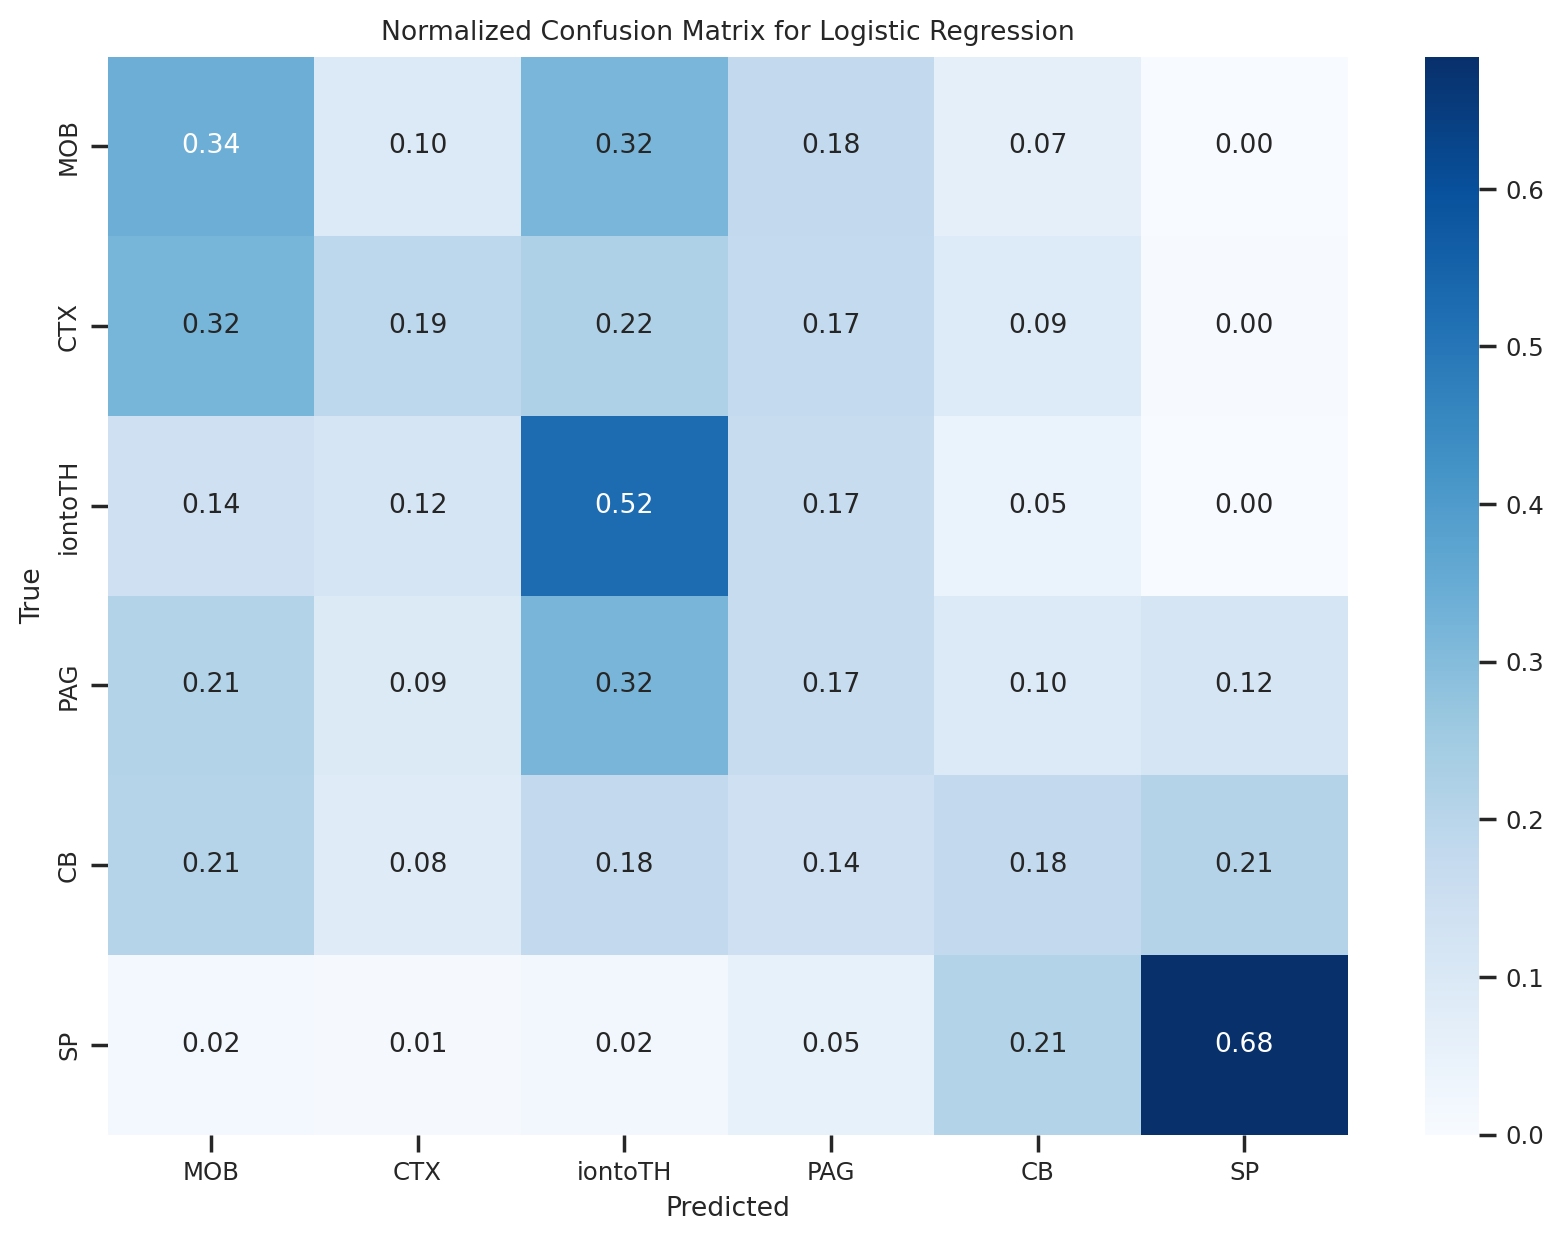

Saved normalized confusion matrix to: /results/normalized_confusion_matrix_logistic_regression_with_scaling.csv
Sample values from confusion matrix:
[[0.34131737 0.10179641]
 [0.32543103 0.18965517]]


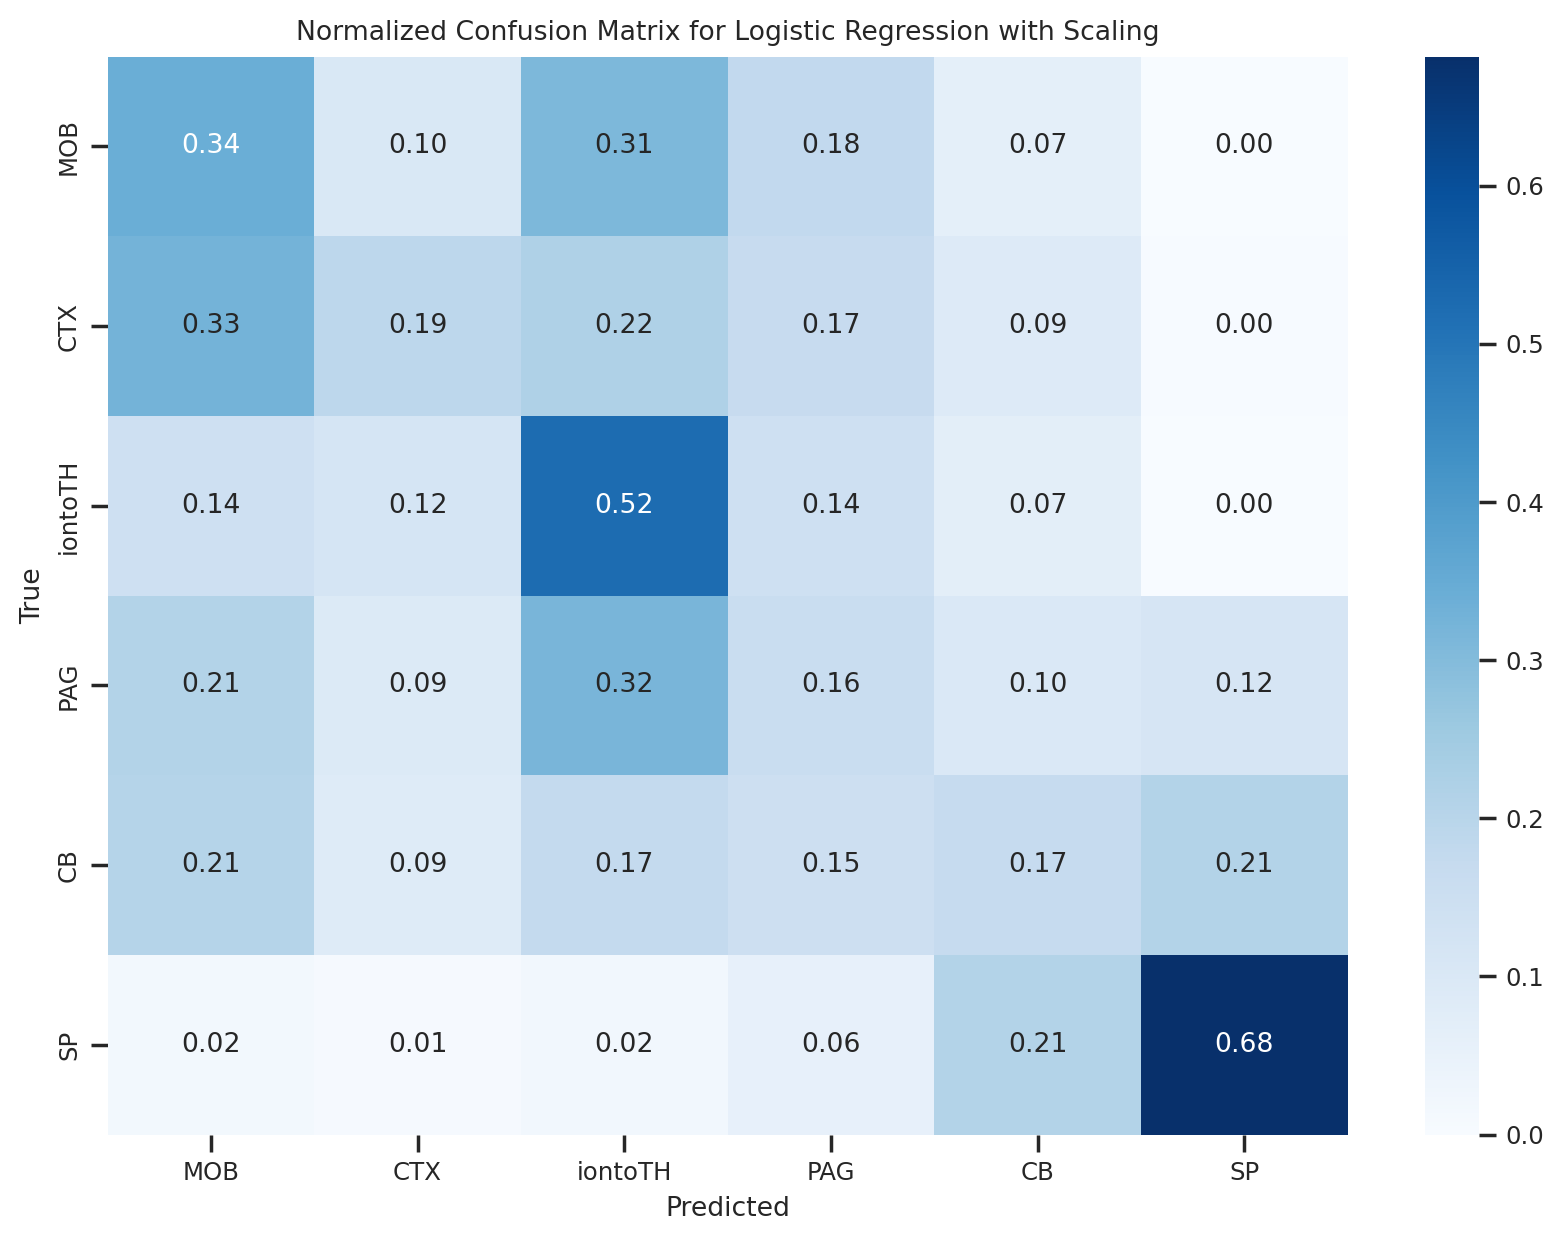

Saved normalized confusion matrix to: /results/normalized_confusion_matrix_random_forest.csv
Sample values from confusion matrix:
[[0.06586826 0.59281437]
 [0.05172414 0.6487069 ]]


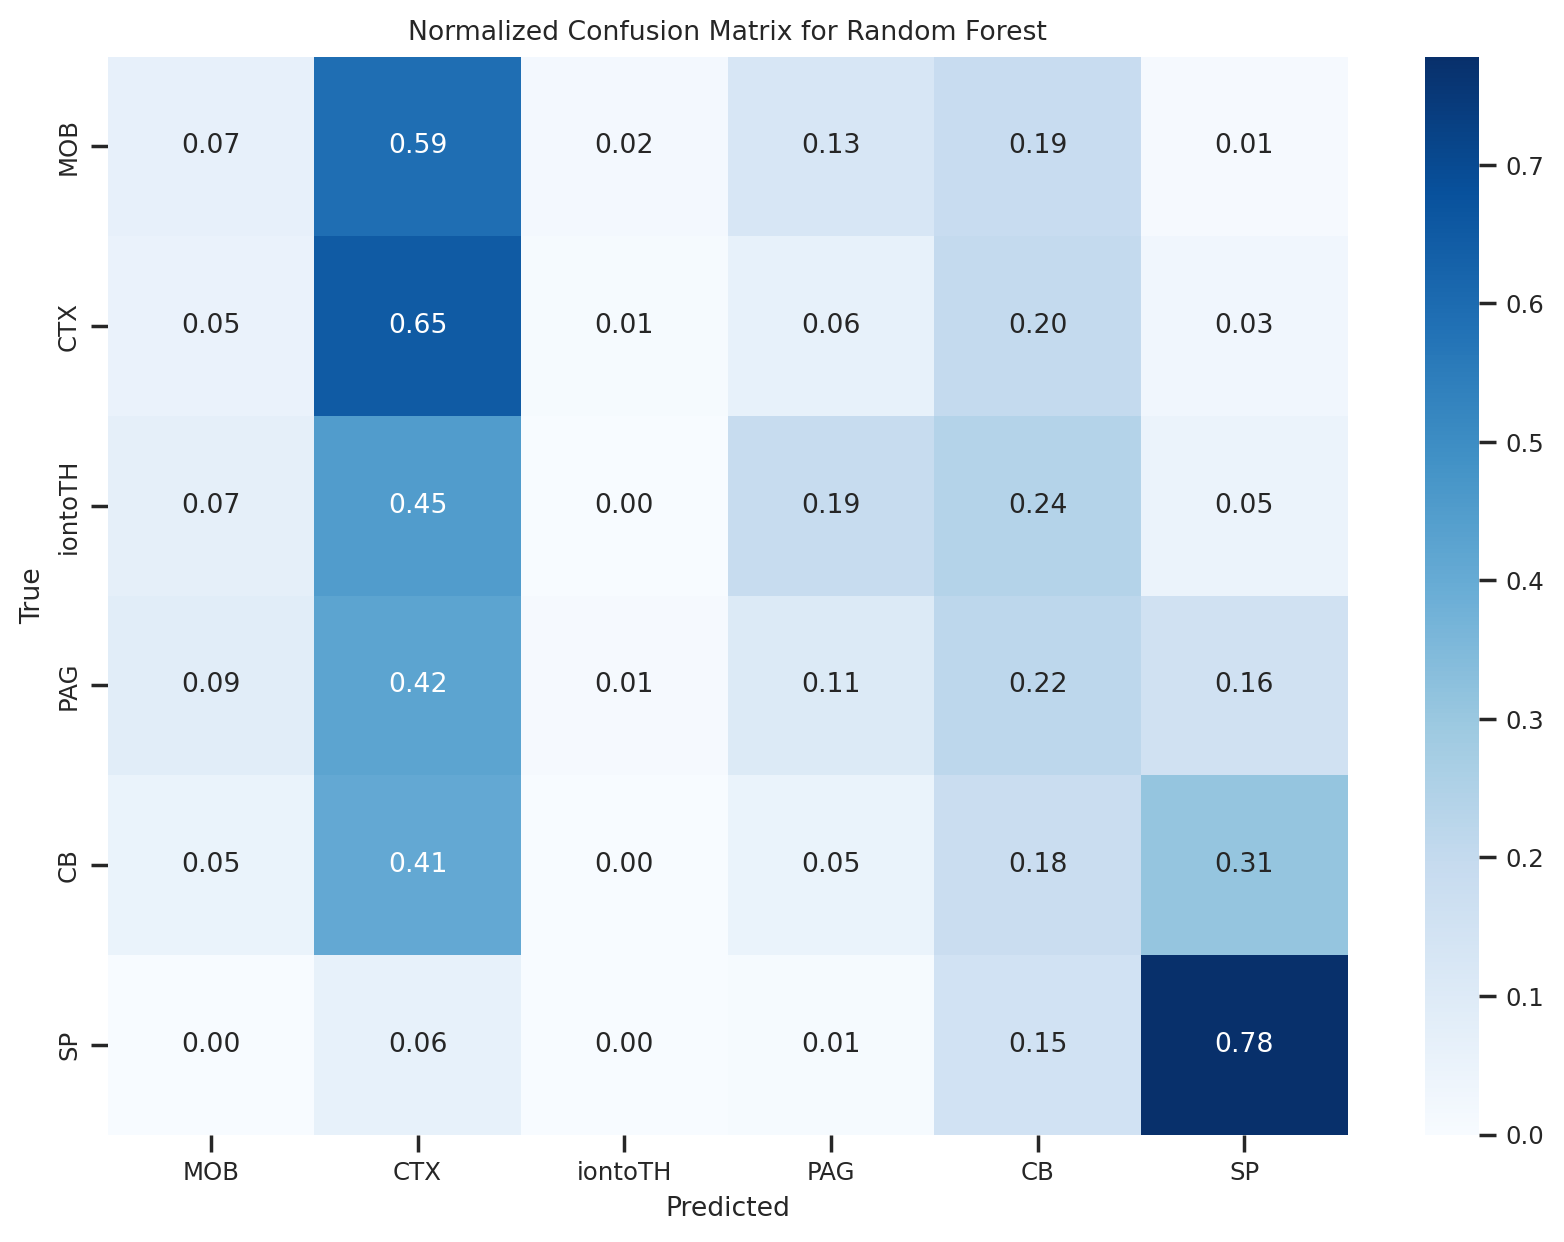

In [13]:
X = df_ipsi[["RC", "ML", "DV"]]
y = df_ipsi["injection_region"]

# Define models
lr = LogisticRegression(max_iter=20000, class_weight='balanced', random_state=42)
lr_pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=20000, class_weight='balanced', random_state=42))
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

# Define cross-validation strategy
min_class_n = y.value_counts().min()
n_splits = min(5, int(min_class_n))
if n_splits < 2:
    raise ValueError("Not enough samples per class for StratifiedKFold.")
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Perform cross-validation on original data
lr_scores = cross_val_score(lr, X, y, cv=cv, scoring='accuracy')
lr_pipeline_scores = cross_val_score(lr_pipeline, X, y, cv=cv, scoring='accuracy')
rf_scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')

# Calculate mean and standard deviation of cross-validation scores
lr_mean = np.mean(lr_scores)
lr_std = np.std(lr_scores)
lr_pipeline_mean = np.mean(lr_pipeline_scores)
lr_pipeline_std = np.std(lr_pipeline_scores)
rf_mean = np.mean(rf_scores)
rf_std = np.std(rf_scores)

print(f"Logistic Regression cross-validation accuracy: {lr_mean:.4f} ± {lr_std:.4f}")
print(f"Logistic Regression with scaling cross-validation accuracy: {lr_pipeline_mean:.4f} ± {lr_pipeline_std:.4f}")
print(f"Random Forest cross-validation accuracy: {rf_mean:.4f} ± {rf_std:.4f}")

# Step 1: Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: Train the models on the training set
lr.fit(X_train, y_train)
lr_pipeline.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Step 3: Predict probabilities on the test set
lr_probs = lr.predict_proba(X_test)
lr_pipeline_probs = lr_pipeline.predict_proba(X_test)
rf_probs = rf.predict_proba(X_test)

# Step 4: Calculate mean posterior probabilities (aligned with model class order)
class_names = ["MOB", "CTX", "iontoTH", "PAG", "CB", "SP"]

def print_mean_probs(probs, classes, title):
    print(title)
    mean_probs = probs.mean(axis=0)
    for c, mp in zip(classes, mean_probs):
        print(f"{c}: {mp:.4f}")

print_mean_probs(lr_probs, lr.classes_, "Logistic Regression mean posterior probabilities:")
print_mean_probs(
    lr_pipeline_probs,
    lr_pipeline.named_steps["logisticregression"].classes_,
    "\nLogistic Regression with scaling mean posterior probabilities:"
)
print_mean_probs(rf_probs, rf.classes_, "\nRandom Forest mean posterior probabilities:")

# Step 5: Predict classes on the test set
lr_pred = lr.predict(X_test)
lr_pipeline_pred = lr_pipeline.predict(X_test)
rf_pred = rf.predict(X_test)

# Step 5b: Robust classification reports (this is the D portion)
def safe_report(y_true, y_pred, labels, title):
    print(title)
    print(classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=labels,
        zero_division=0
    ))

safe_report(y_test, lr_pred, class_names, "Logistic Regression classification report:")
safe_report(y_test, lr_pipeline_pred, class_names, "Logistic Regression with scaling classification report:")
safe_report(y_test, rf_pred, class_names, "Random Forest classification report:")

# Step 6: Generate and plot confusion matrices
def plot_confusion_matrix(y_test, y_pred, model_name, normalize=False):
    # Calculate confusion matrix with consistent normalization
    if normalize:
        cm = confusion_matrix(y_test, y_pred, labels=class_names, normalize='true')
    else:
        cm = confusion_matrix(y_test, y_pred, labels=class_names)
    
    # Save normalized confusion matrix to CSV if normalize=True
    if normalize:
        # Create DataFrame with proper labels
        cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
        # Create filename
        filename = f"/results/normalized_confusion_matrix_{model_name.replace(' ', '_').lower()}.csv"
        # Save to CSV
        cm_df.to_csv(filename)
        print(f"Saved normalized confusion matrix to: {filename}")
        print(f"Sample values from confusion matrix:\n{cm[:2, :2]}")  # Debug print
    
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='.2f' if normalize else 'd', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{"Normalized " if normalize else ""}Confusion Matrix for {model_name}')
    plt.show()

# Plot normalized confusion matrices for each model
plot_confusion_matrix(y_test, lr_pred, "Logistic Regression", normalize=True)
plot_confusion_matrix(y_test, lr_pipeline_pred, "Logistic Regression with Scaling", normalize=True)
plot_confusion_matrix(y_test, rf_pred, "Random Forest", normalize=True)

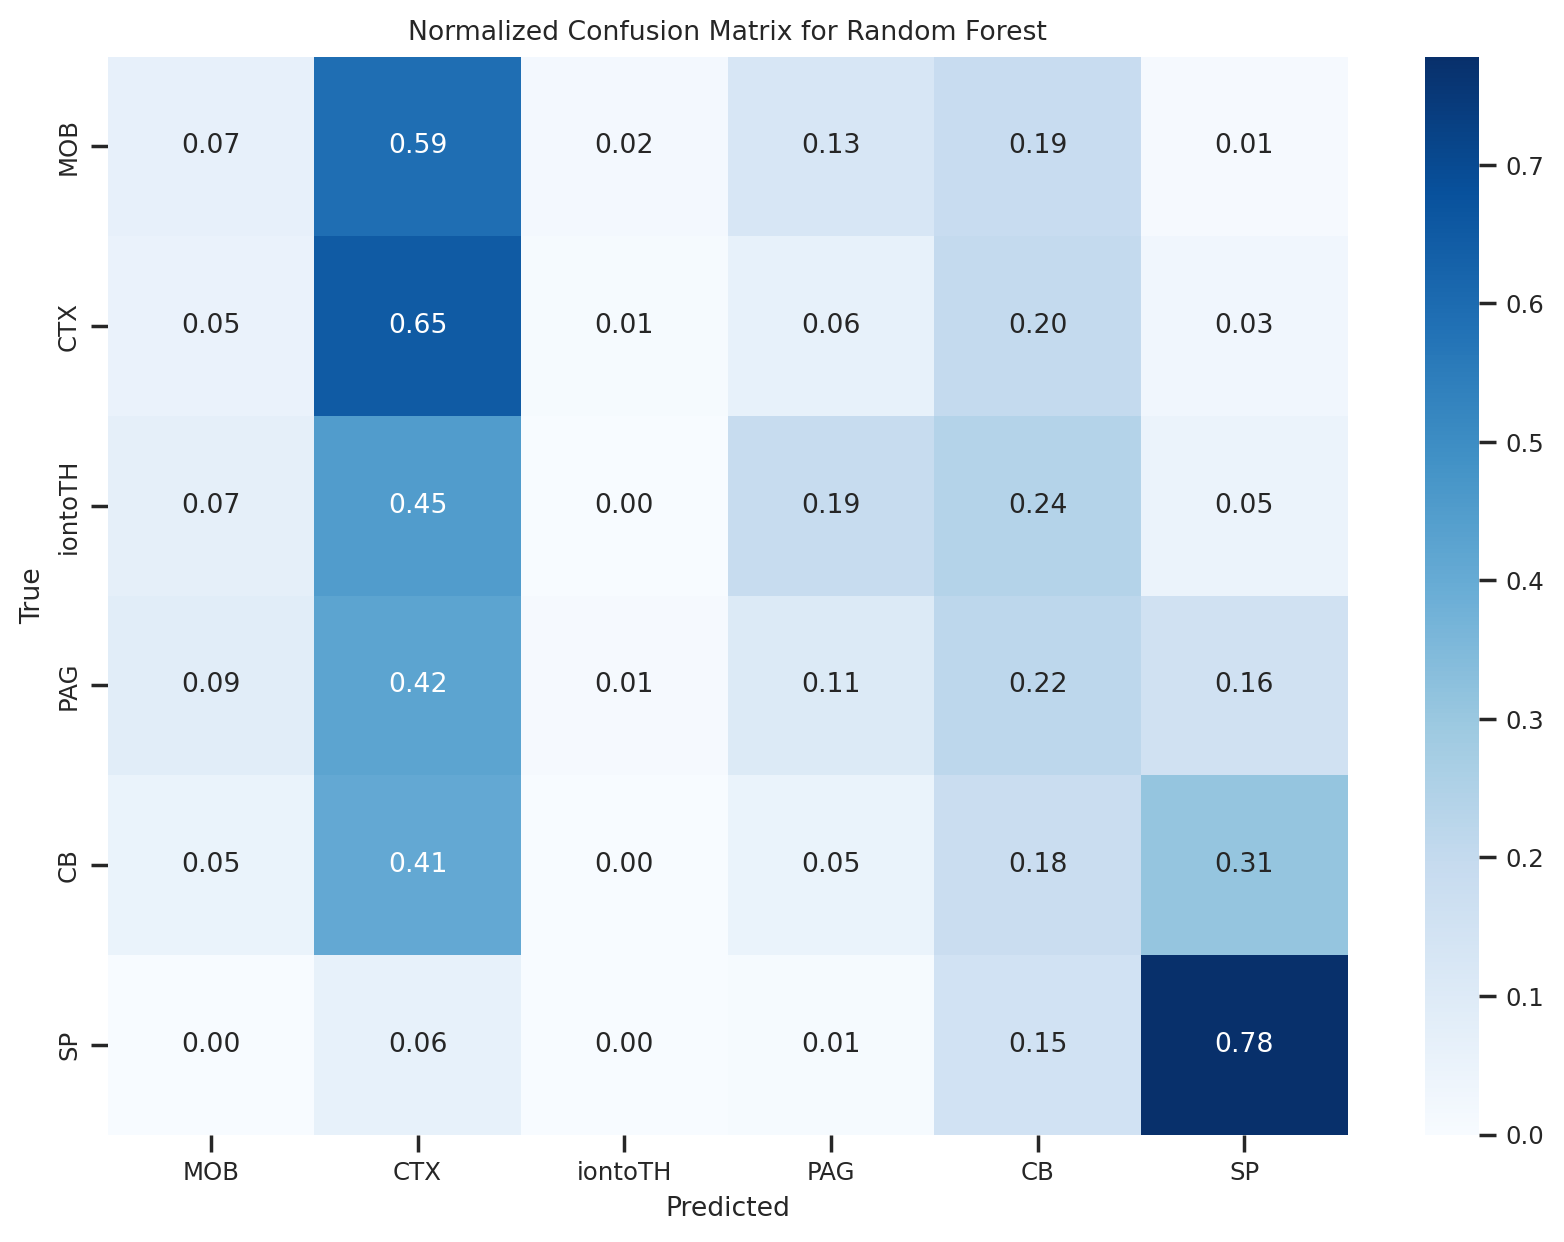

In [14]:
# save normalized confusion matrix for random forest plot as a pdf figure to results/plots
fig, ax = plt.subplots(figsize=(10, 7))
cm = confusion_matrix(y_test, rf_pred, labels=class_names, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix for Random Forest')

# Ensure fonts are embedded and text remains editable
from matplotlib import rcParams
rcParams['svg.fonttype'] = 'none'  # Do not convert text to paths in SVG
rcParams['pdf.fonttype'] = 42      # Embed fonts in PDF

from pathlib import Path
out_dir = Path("/results/plots")
out_dir.mkdir(parents=True, exist_ok=True)
# Save the plot
fig.savefig(out_dir / "normalized_confusion_matrix_random_forest.pdf")
fig.savefig(out_dir / "normalized_confusion_matrix_random_forest.svg")
plt.show()


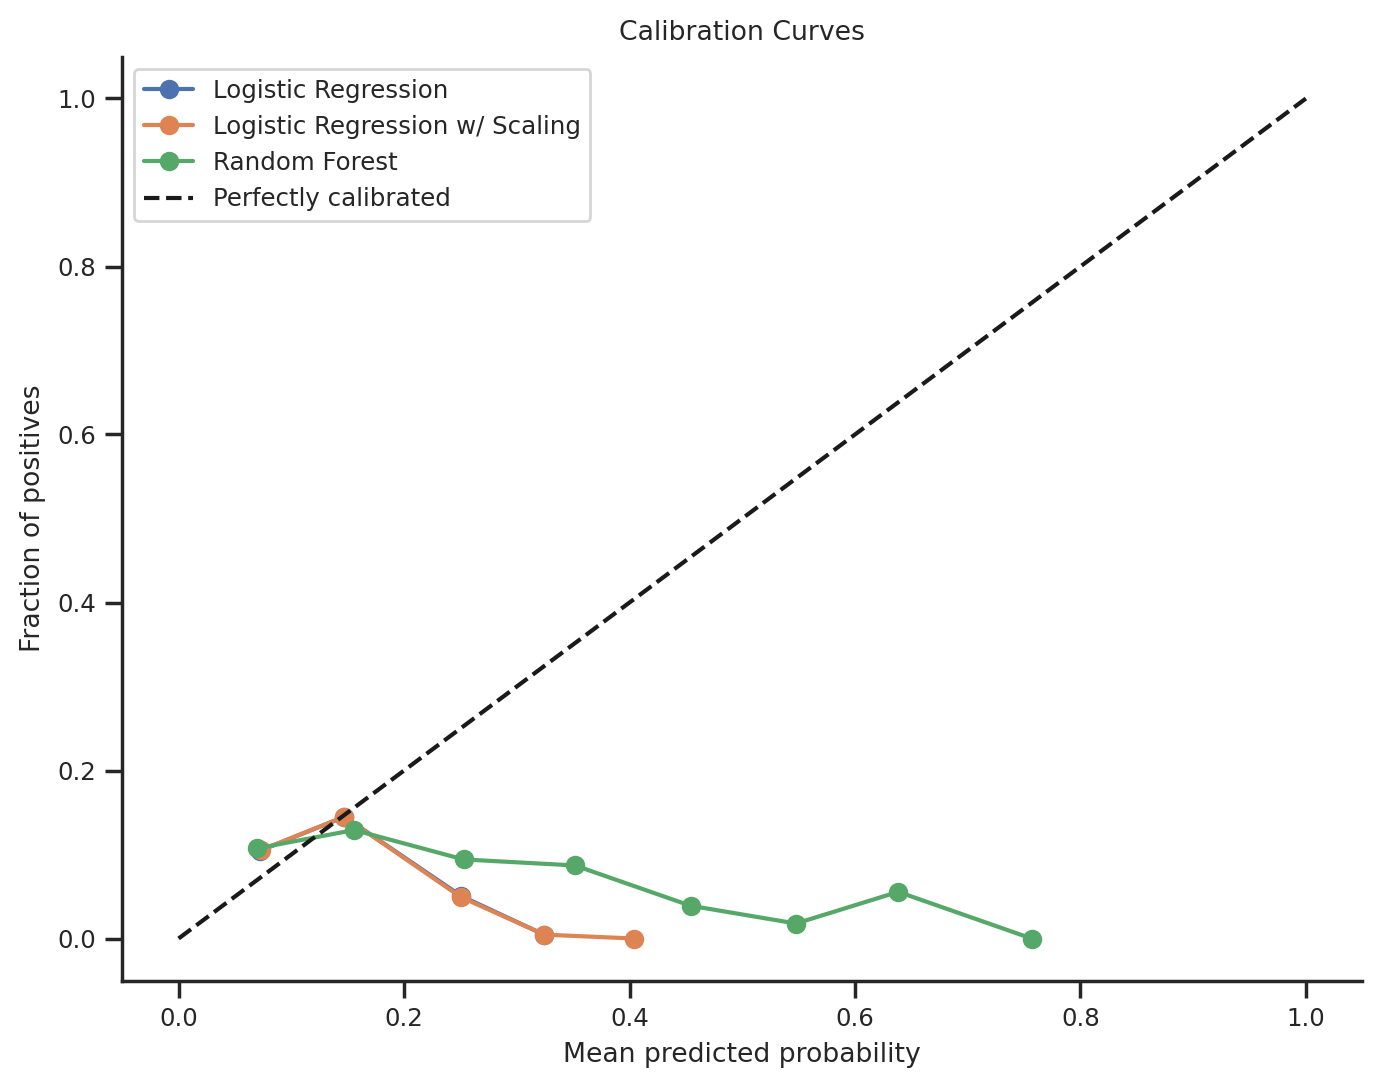

In [15]:
from sklearn.calibration import calibration_curve
plt.figure(figsize=(8,6))
for model, probs, name in [
    (lr, lr_probs, "Logistic Regression"),
    (lr_pipeline, lr_pipeline_probs, "Logistic Regression w/ Scaling"),
    (rf, rf_probs, "Random Forest")
]:
    # Use probabilities for one class (e.g., first class)
    prob_true, prob_pred = calibration_curve(y_test == class_names[0], probs[:,0], n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=name)

plt.plot([0,1],[0,1],'k--', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curves')
plt.legend()
plt.show()

In [16]:
# Gaussian Process Classification with Model Caching
# Load data
coordinates = df_ipsi[['RC', 'DV', 'ML']].values
target = df_ipsi['injection_region'].values

# Path to attached data asset (read-only, persistent)
model_file_data_asset = Path("/data/manually_proofed_Ai65_classifier/gp_classification_results.pkl")

# Check if model exists in attached data asset
if model_file_data_asset.exists():
    print(f"Loading model from data asset: {model_file_data_asset}")
    with open(model_file_data_asset, 'rb') as f:
        results = pickle.load(f)
    gp = results['gp_model']
    label_encoder = results['label_encoder']
    y_pred_classes = results['y_pred_classes']
    y_pred_proba = results['y_pred_proba']
    y_pred = results['y_pred']
    sigma = results['sigma']
    category_mapping = results['category_mapping']
    print("Model loaded from data asset!")

else:
    print("Training new model...")
    
    # Label encoder
    label_encoder = LabelEncoder()
    target_encoded = label_encoder.fit_transform(target)
    
    # Define GP with larger bounds to avoid convergence warnings
    kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e4))
    gp = GaussianProcessClassifier(kernel=kernel, n_restarts_optimizer=10, random_state=42)
    
    # Fit model
    gp.fit(coordinates, target)
    
    # Make predictions
    y_pred_classes = gp.predict(coordinates)
    y_pred_proba = gp.predict_proba(coordinates)
    y_pred = label_encoder.transform(y_pred_classes)
    
    # Calculate uncertainty
    sigma = -np.sum(y_pred_proba * np.log(y_pred_proba + 1e-10), axis=1)
    
    # Category mapping
    category_mapping = {i: label for i, label in enumerate(label_encoder.classes_)}
    
    # Save results to /results for download/promotion to data asset
    results = {
        'gp_model': gp,
        'label_encoder': label_encoder,
        'y_pred_classes': y_pred_classes,
        'y_pred_proba': y_pred_proba,
        'y_pred': y_pred,
        'sigma': sigma,
        'coordinates': coordinates,
        'target': target,
        'category_mapping': category_mapping
    }
    
    Path("/results").mkdir(parents=True, exist_ok=True)
    model_file_results = Path("/results/gp_classification_results.pkl")
    with open(model_file_results, 'wb') as f:
        pickle.dump(results, f)
    print(f"Model saved to {model_file_results}")
    print(f"File size: {model_file_results.stat().st_size / (1024*1024):.2f} MB")
    print("Next: download from /results and create a new data asset to attach to this capsule.")

Loading model from data asset: /data/manually_proofed_Ai65_classifier/gp_classification_results.pkl
Model loaded from data asset!


Numeric to Categorical Mapping: {0: 'CB', 1: 'CTX', 2: 'MOB', 3: 'PAG', 4: 'SP', 5: 'iontoTH'}


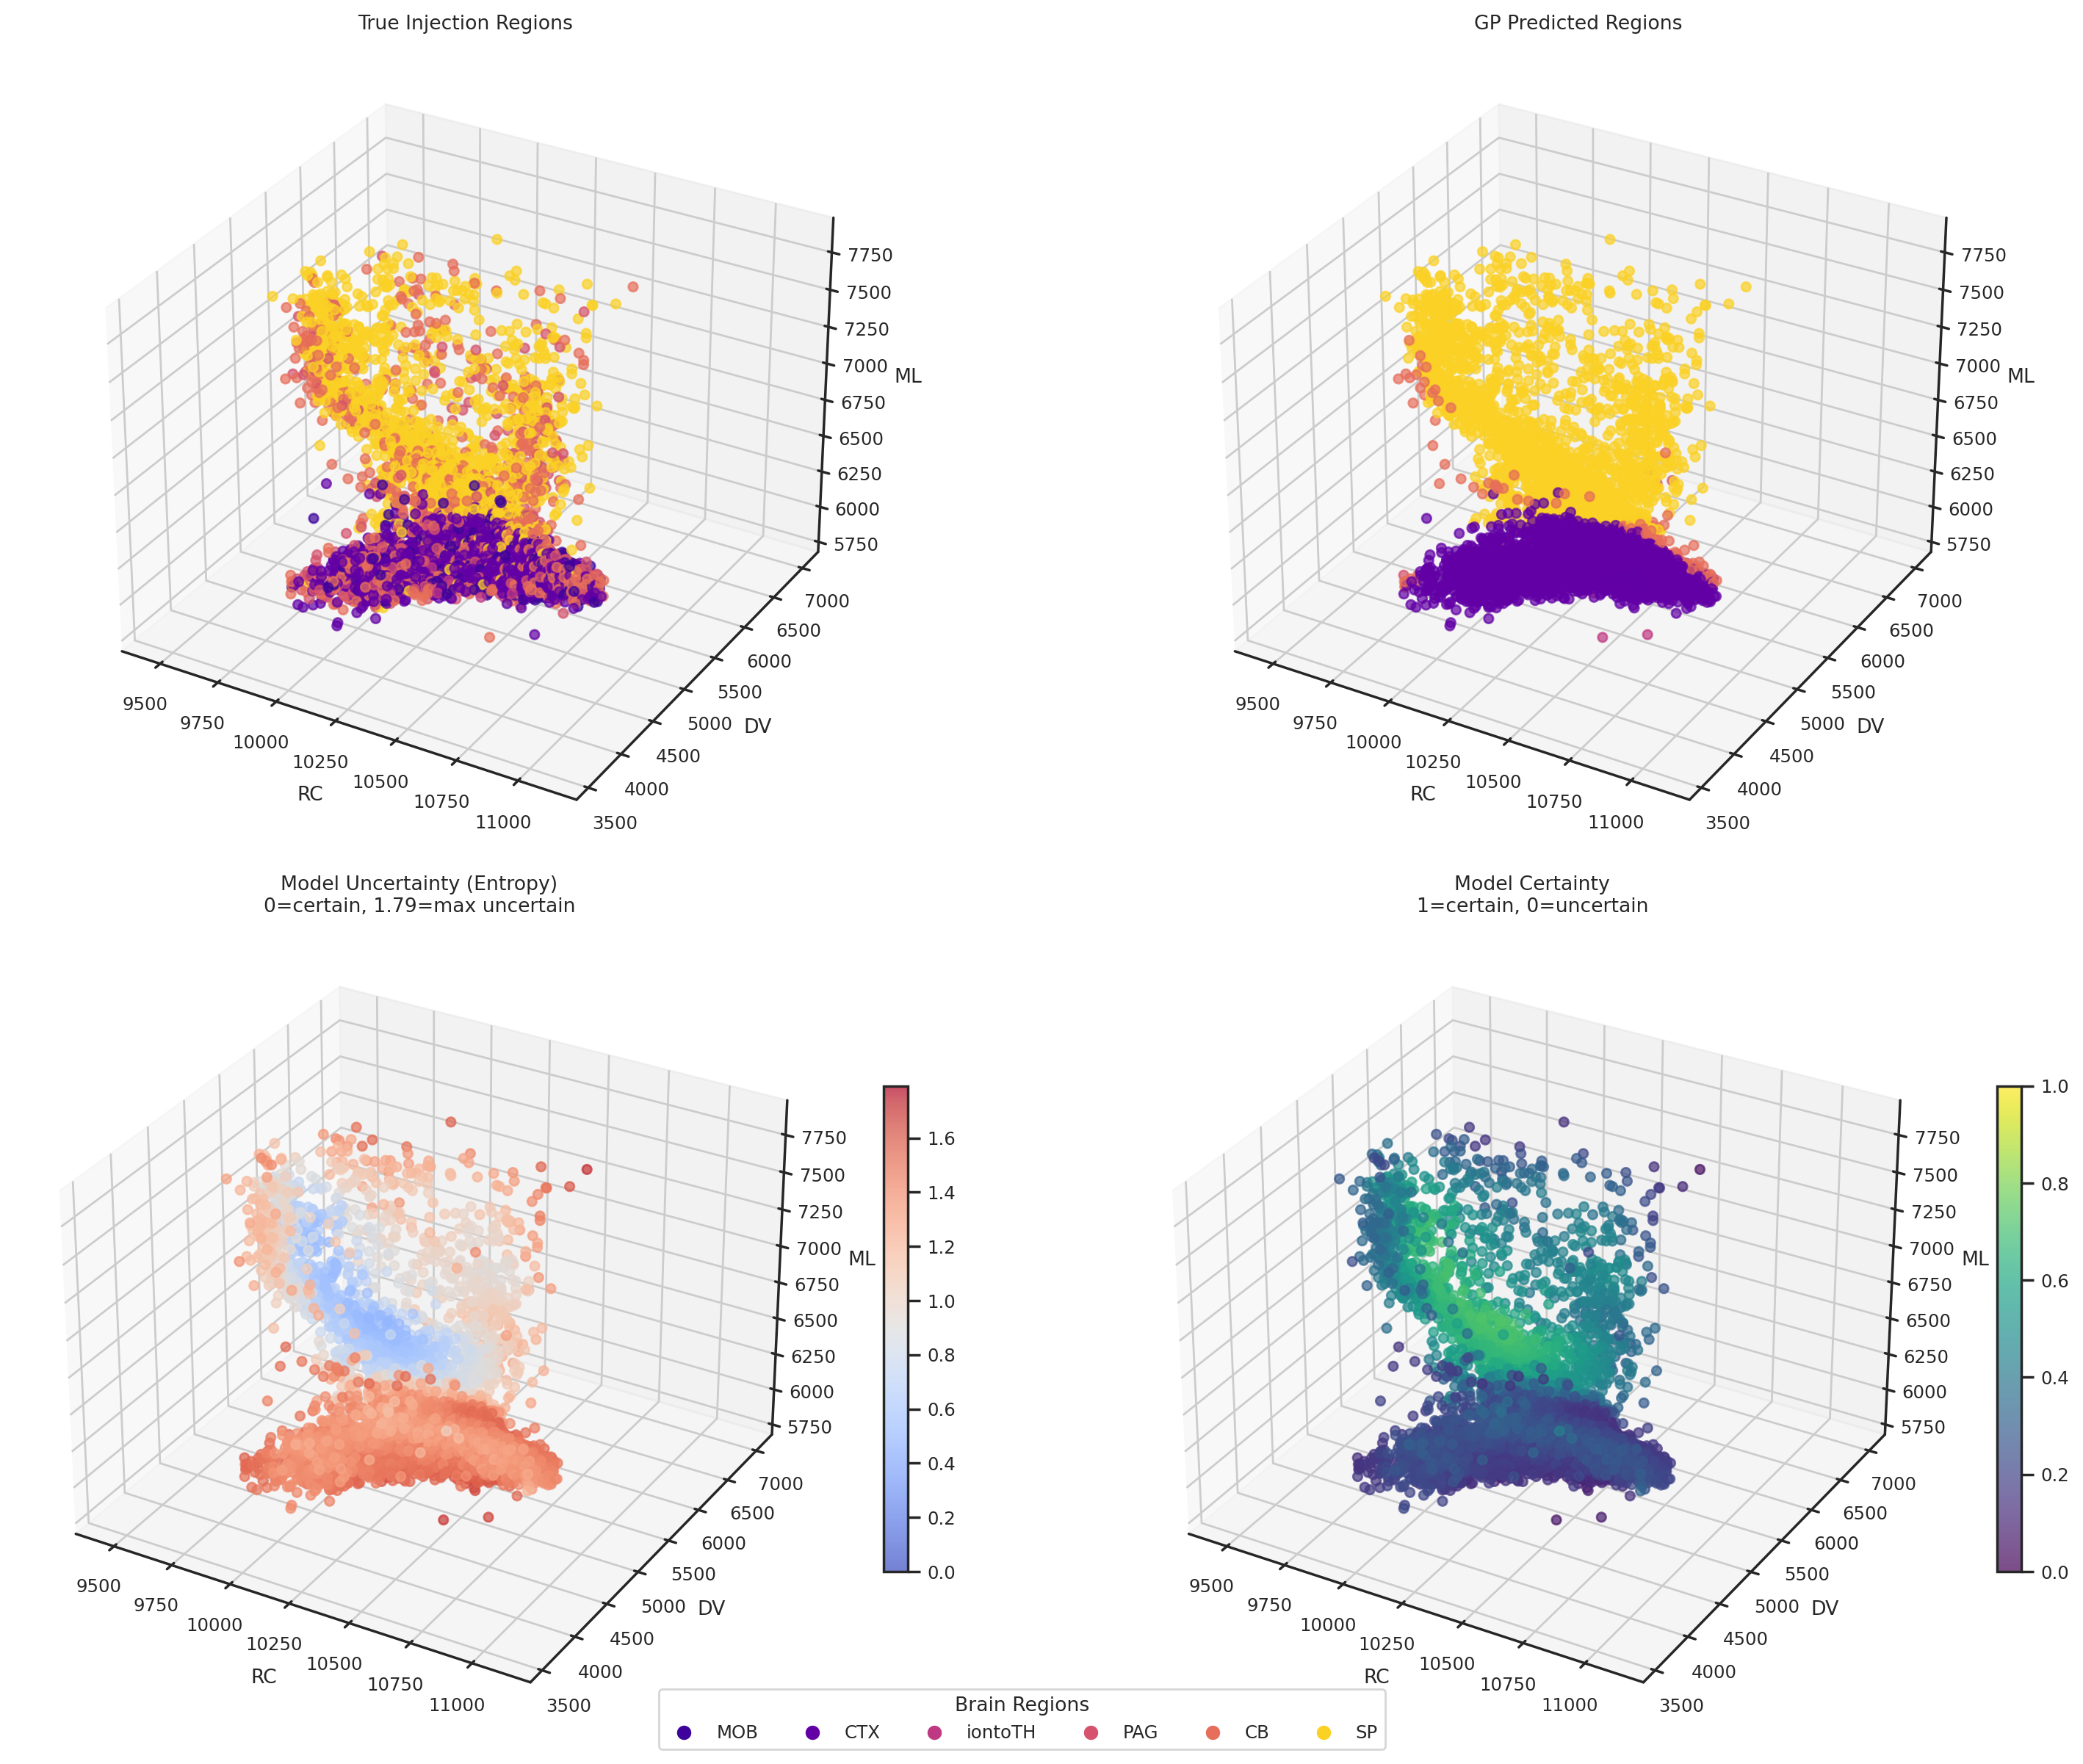


Model Performance Summary:
Entropy range: 0.489 to 1.720 (theoretical max: 1.792)
Mean certainty: 0.275 ± 0.169
Most certain predictions: 0.727
Least certain predictions: 0.040


In [17]:
# Consolidated Model Evaluation and Uncertainty Visualization
category_mapping = {i: label for i, label in enumerate(label_encoder.classes_)}
print("Numeric to Categorical Mapping:", category_mapping)

# Map predicted classes to colors
predicted_colors = [region_col_map[pred_class] for pred_class in y_pred_classes]
colors_true = df_ipsi['injection_region'].map(region_col_map)

# Create comprehensive comparison plot (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(16, 12), subplot_kw={'projection': '3d'})

# Plot 1: True regions
axes[0,0].scatter(coordinates[:, 0], coordinates[:, 1], coordinates[:, 2], 
                  c=colors_true, marker='o', alpha=0.7, s=20)
axes[0,0].set_xlabel('RC')
axes[0,0].set_ylabel('DV')
axes[0,0].set_zlabel('ML')
axes[0,0].set_title('True Injection Regions')

# Plot 2: Predicted regions
axes[0,1].scatter(coordinates[:, 0], coordinates[:, 1], coordinates[:, 2], 
                  c=predicted_colors, marker='o', alpha=0.7, s=20)
axes[0,1].set_xlabel('RC')
axes[0,1].set_ylabel('DV')
axes[0,1].set_zlabel('ML')
axes[0,1].set_title('GP Predicted Regions')

# Plot 3: Model uncertainty (raw entropy)
n_classes = len(label_encoder.classes_)
sc1 = axes[1,0].scatter(coordinates[:, 0], coordinates[:, 1], coordinates[:, 2], 
                       c=sigma, cmap='coolwarm', marker='o', alpha=0.7, s=20,
                       vmin=0, vmax=np.log(n_classes))
axes[1,0].set_xlabel('RC')
axes[1,0].set_ylabel('DV')
axes[1,0].set_zlabel('ML')
axes[1,0].set_title('Model Uncertainty (Entropy)\n0=certain, 1.79=max uncertain')
plt.colorbar(sc1, ax=axes[1,0], shrink=0.6)

# Plot 4: Model certainty (normalized)
normalized_sigma = sigma / np.log(n_classes)
certainty = 1 - normalized_sigma
sc2 = axes[1,1].scatter(coordinates[:, 0], coordinates[:, 1], coordinates[:, 2], 
                       c=certainty, cmap='viridis', marker='o', alpha=0.7, s=20,
                       vmin=0, vmax=1)
axes[1,1].set_xlabel('RC')
axes[1,1].set_ylabel('DV')
axes[1,1].set_zlabel('ML')
axes[1,1].set_title('Model Certainty\n1=certain, 0=uncertain')
plt.colorbar(sc2, ax=axes[1,1], shrink=0.6)

# Add shared legend for region colors
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, 
                      markersize=8, label=region) for region, color in region_col_map.items()]
fig.legend(handles=handles, title='Brain Regions', loc='center', bbox_to_anchor=(0.5, 0.02), ncol=6)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nModel Performance Summary:")
print(f"Entropy range: {sigma.min():.3f} to {sigma.max():.3f} (theoretical max: {np.log(n_classes):.3f})")
print(f"Mean certainty: {certainty.mean():.3f} ± {certainty.std():.3f}")
print(f"Most certain predictions: {certainty.max():.3f}")
print(f"Least certain predictions: {certainty.min():.3f}")

In [18]:
# Comprehensive Entropy Analysis and Class Statistics
n_classes = len(label_encoder.classes_)
max_entropy = np.log(n_classes)
normalized_entropy = sigma / max_entropy

# Create entropy dataframe for analysis
entropy_df = pd.DataFrame({
    'entropy': sigma,
    'normalized_entropy': normalized_entropy,
    'predicted_class': y_pred_classes,
    'true_class': target
})

print(f"Entropy Analysis Summary:")
print(f"Number of classes: {n_classes}")
print(f"Class names: {list(label_encoder.classes_)}")
print(f"Entropy bounds: 0 (perfect) to {max_entropy:.3f} (maximum uncertainty)")
print(f"Actual range: {sigma.min():.3f} to {sigma.max():.3f} (mean: {sigma.mean():.3f})")

# Class-wise statistics with consistent calculations
print(f"\nPrediction Statistics by Class:")
class_stats = []
for class_name in label_encoder.classes_:
    class_mask = entropy_df['predicted_class'] == class_name
    class_entropies = entropy_df[class_mask]['entropy']
    
    if len(class_entropies) > 0:
        # Calculate certainty consistently using normalized entropy
        class_normalized_entropy = class_entropies / max_entropy
        mean_certainty = (1 - class_normalized_entropy).mean()
        
        stats = {
            'class': class_name,
            'count': len(class_entropies),
            'mean_entropy': class_entropies.mean(),
            'mean_certainty': mean_certainty
        }
    else:
        stats = {
            'class': class_name, 'count': 0,
            'mean_entropy': np.nan, 'mean_certainty': np.nan
        }
    class_stats.append(stats)

# Display results - handle NaN values manually for compatibility
stats_df = pd.DataFrame(class_stats)
# Separate rows with and without NaN values
valid_stats = stats_df.dropna(subset=['mean_entropy']).sort_values('mean_entropy')
nan_stats = stats_df[stats_df['mean_entropy'].isna()]
# Combine them (NaN values at the end)
stats_df = pd.concat([valid_stats, nan_stats], ignore_index=True)

print(f"{'Class':<10} {'Count':<7} {'Mean Entropy':<12} {'Mean Certainty':<15}")
print("-" * 50)
for _, row in stats_df.iterrows():
    if row['count'] > 0:
        print(f"{row['class']:<10} {row['count']:<7} {row['mean_entropy']:.3f}        {row['mean_certainty']:.3f}")
    else:
        print(f"{row['class']:<10} {row['count']:<7} {'Not predicted':<25}")

# Check for unpredicted classes
unpredicted = stats_df[stats_df['count'] == 0]['class'].tolist()
if unpredicted:
    print(f"\n⚠️ Warning: {len(unpredicted)} classes never predicted: {unpredicted}")

# Verify overall certainty calculation matches individual calculations
overall_certainty = (1 - normalized_entropy).mean()
overall_certainty_std = (1 - normalized_entropy).std()
print(f"\nOverall certainty: {overall_certainty:.3f} ± {overall_certainty_std:.3f}")

# Verification: Check that individual class certainties match overall calculation
print(f"\n🔍 CALCULATION VERIFICATION:")
print(f"Method 1 (overall): {overall_certainty:.3f}")
weighted_mean_certainty = sum(row['mean_certainty'] * row['count'] 
                             for _, row in valid_stats.iterrows() if not pd.isna(row['mean_certainty'])) / valid_stats['count'].sum()
print(f"Method 2 (weighted avg of classes): {weighted_mean_certainty:.3f}")
print(f"✅ Match: {abs(overall_certainty - weighted_mean_certainty) < 0.001}")

Entropy Analysis Summary:
Number of classes: 6
Class names: ['CB', 'CTX', 'MOB', 'PAG', 'SP', 'iontoTH']
Entropy bounds: 0 (perfect) to 1.792 (maximum uncertainty)
Actual range: 0.489 to 1.720 (mean: 1.299)

Prediction Statistics by Class:
Class      Count   Mean Entropy Mean Certainty 
--------------------------------------------------
SP         2701    0.919        0.487
CB         577     1.461        0.185
CTX        5207    1.474        0.177
PAG        64      1.599        0.108
MOB        14      1.617        0.098
iontoTH    2       1.676        0.065

Overall certainty: 0.275 ± 0.169

🔍 CALCULATION VERIFICATION:
Method 1 (overall): 0.275
Method 2 (weighted avg of classes): 0.275
✅ Match: True


SUMMARY TABLE: MODEL CERTAINTY BY PREDICTED CLASS
Class    N      Mean Certainty  ±SEM     Confidence Level
------------------------------------------------------------
SP       2701   0.487          ±0.003   Moderate       
CB       577    0.185          ±0.003   Low            
CTX      5207   0.177          ±0.001   Low            
PAG      64     0.108          ±0.006   Low            
MOB      14     0.098          ±0.001   Low            
iontoTH  2      0.065          ±0.009   Low            


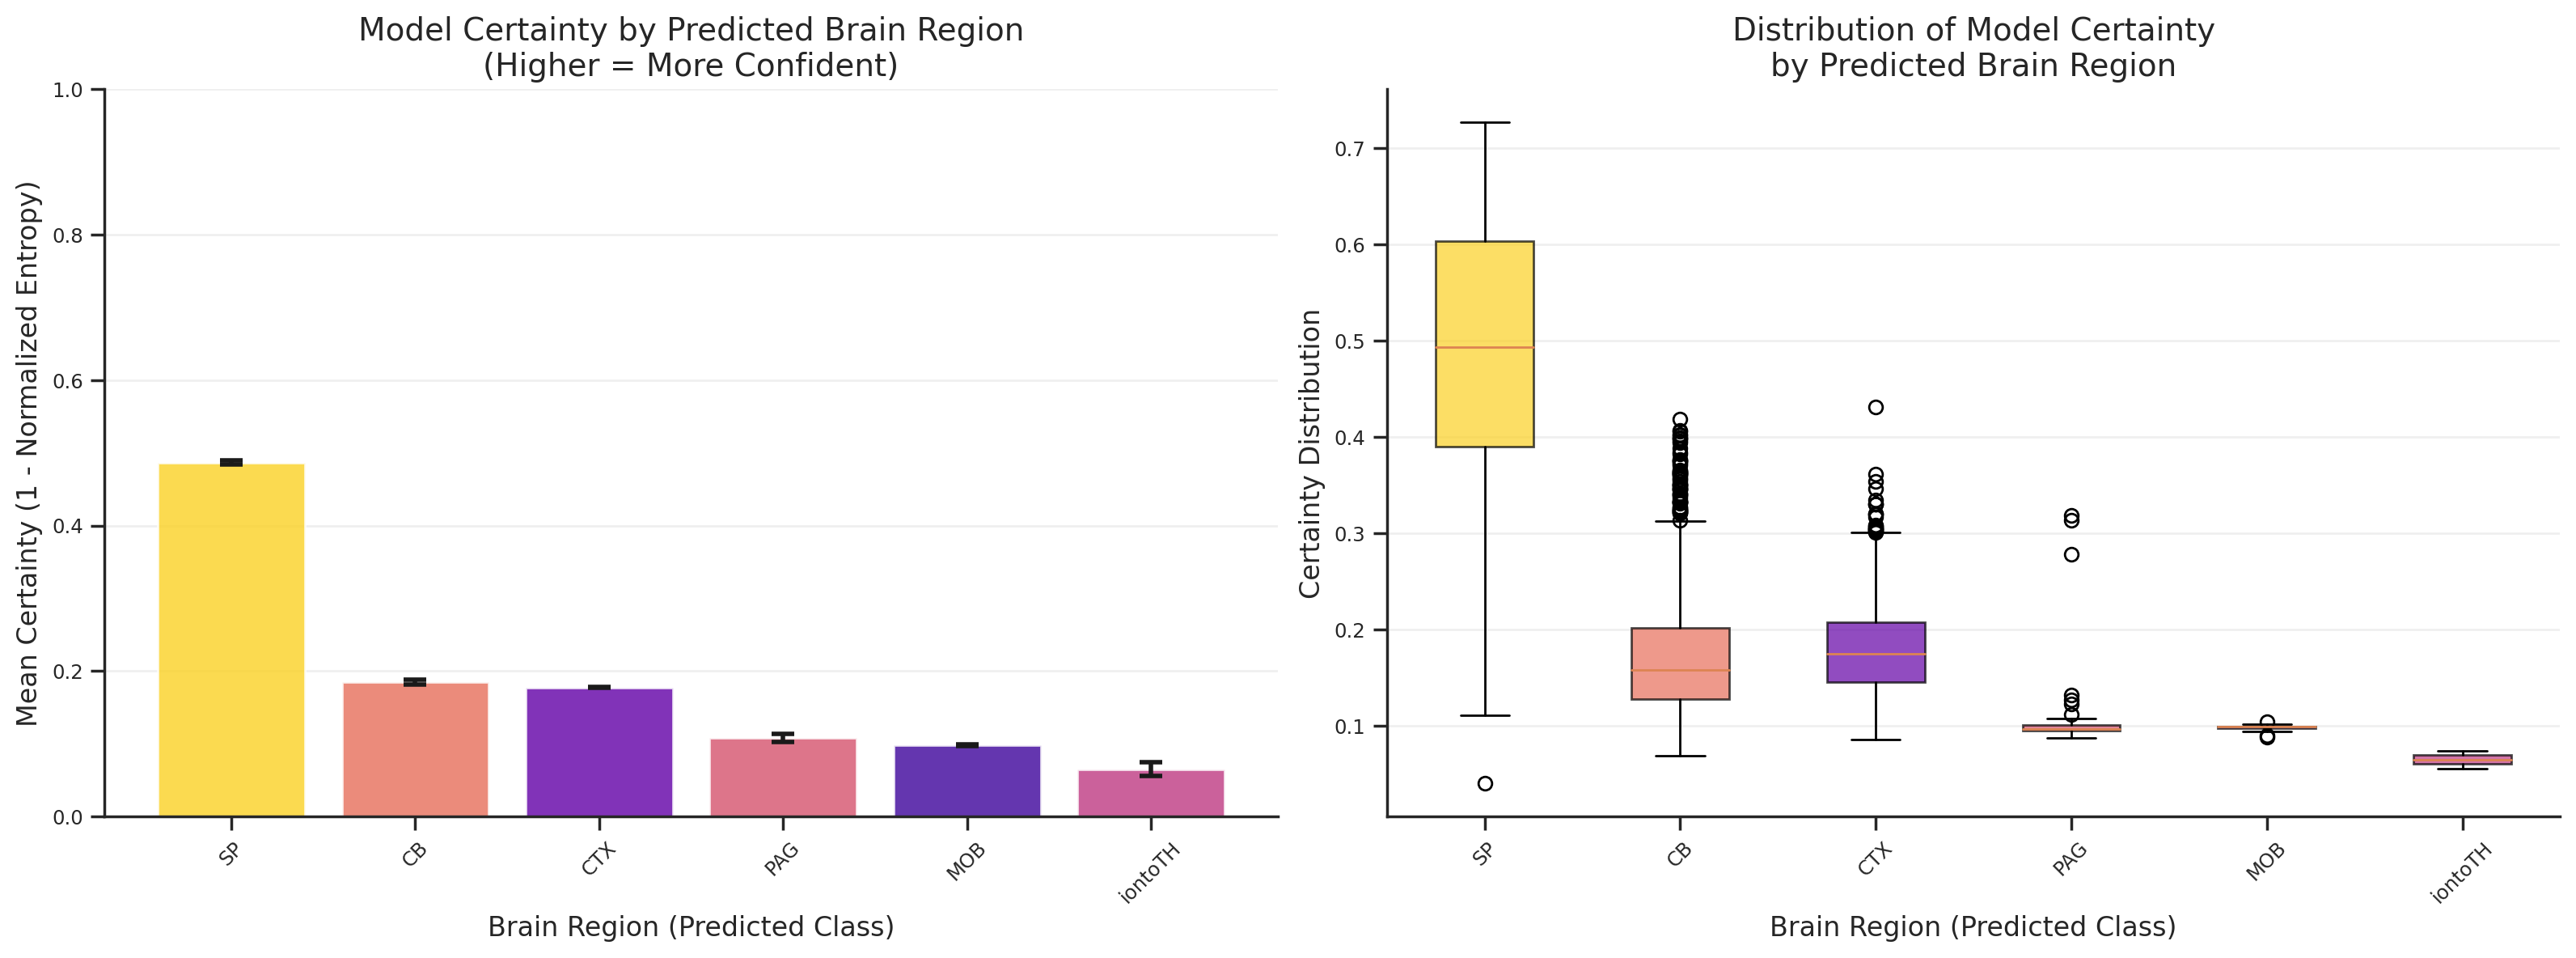


SUMMARY STATISTICS:
Overall mean certainty: 0.275 ± 0.002
Most confident predictions: SP (certainty: 0.487)
Least confident predictions: iontoTH (certainty: 0.065)

ANOVA test for differences between classes:
F-statistic: 4635.496, p-value: 0.00e+00
*** Highly significant differences in certainty between brain regions (p < 0.001)


In [19]:
# Visual Summary: Average Certainty per Class with SEM
from scipy import stats

# Calculate certainty (inverse of normalized entropy) and SEM for each class
certainty_stats = []
for class_name in label_encoder.classes_:
    class_mask = entropy_df['predicted_class'] == class_name
    class_entropies = entropy_df[class_mask]['normalized_entropy']
    
    if len(class_entropies) > 0:
        # Certainty = 1 - normalized_entropy (so higher values = more certain)
        class_certainties = 1 - class_entropies
        
        mean_certainty = class_certainties.mean()
        sem_certainty = stats.sem(class_certainties)  # Standard Error of Mean
        
        certainty_stats.append({
            'class': class_name,
            'count': len(class_certainties),
            'mean_certainty': mean_certainty,
            'sem_certainty': sem_certainty,
            'mean_entropy': entropy_df[class_mask]['entropy'].mean(),
            'color': region_col_map[class_name]
        })

# Convert to DataFrame and sort by certainty (highest first)
certainty_df = pd.DataFrame(certainty_stats)
certainty_df = certainty_df.sort_values('mean_certainty', ascending=False)

# Create summary table
print("SUMMARY TABLE: MODEL CERTAINTY BY PREDICTED CLASS")
print("="*60)
print(f"{'Class':<8} {'N':<6} {'Mean Certainty':<15} {'±SEM':<8} {'Confidence Level':<15}")
print("-" * 60)

for _, row in certainty_df.iterrows():
    confidence_level = "Very High" if row['mean_certainty'] > 0.8 else \
                      "High" if row['mean_certainty'] > 0.6 else \
                      "Moderate" if row['mean_certainty'] > 0.4 else \
                      "Low"
    
    print(f"{row['class']:<8} {row['count']:<6} {row['mean_certainty']:.3f}          "
          f"±{row['sem_certainty']:.3f}   {confidence_level:<15}")

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot with error bars (SEM)
x_pos = range(len(certainty_df))
colors = [row['color'] for _, row in certainty_df.iterrows()]

bars = ax1.bar(x_pos, certainty_df['mean_certainty'], 
               yerr=certainty_df['sem_certainty'],
               color=colors, alpha=0.8, capsize=5, 
               error_kw={'linewidth': 2, 'capthick': 2})

ax1.set_xlabel('Brain Region (Predicted Class)', fontsize=12)
ax1.set_ylabel('Mean Certainty (1 - Normalized Entropy)', fontsize=12)
ax1.set_title('Model Certainty by Predicted Brain Region\n(Higher = More Confident)', fontsize=14)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(certainty_df['class'], rotation=45)
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

# Box plot showing distribution of certainties
certainty_data = []
certainty_labels = []
certainty_colors = []

for _, row in certainty_df.iterrows():
    class_mask = entropy_df['predicted_class'] == row['class']
    class_certainties = 1 - entropy_df[class_mask]['normalized_entropy']
    certainty_data.append(class_certainties)
    certainty_labels.append(row['class'])
    certainty_colors.append(row['color'])

bp = ax2.boxplot(certainty_data, labels=certainty_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], certainty_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_xlabel('Brain Region (Predicted Class)', fontsize=12)
ax2.set_ylabel('Certainty Distribution', fontsize=12)
ax2.set_title('Distribution of Model Certainty\nby Predicted Brain Region', fontsize=14)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nSUMMARY STATISTICS:")
print(f"Overall mean certainty: {(1 - normalized_entropy).mean():.3f} ± {stats.sem(1 - normalized_entropy):.3f}")
print(f"Most confident predictions: {certainty_df.iloc[0]['class']} (certainty: {certainty_df.iloc[0]['mean_certainty']:.3f})")
print(f"Least confident predictions: {certainty_df.iloc[-1]['class']} (certainty: {certainty_df.iloc[-1]['mean_certainty']:.3f})")

# Statistical significance testing (ANOVA)
from scipy.stats import f_oneway
certainty_groups = [1 - entropy_df[entropy_df['predicted_class'] == cls]['normalized_entropy'] 
                   for cls in label_encoder.classes_ if cls in entropy_df['predicted_class'].values]
if len(certainty_groups) > 1:
    f_stat, p_value = f_oneway(*certainty_groups)
    print(f"\nANOVA test for differences between classes:")
    print(f"F-statistic: {f_stat:.3f}, p-value: {p_value:.2e}")
    if p_value < 0.001:
        print("*** Highly significant differences in certainty between brain regions (p < 0.001)")
    elif p_value < 0.01:
        print("** Significant differences in certainty between brain regions (p < 0.01)")
    elif p_value < 0.05:
        print("* Significant differences in certainty between brain regions (p < 0.05)")
    else:
        print("No significant differences in certainty between brain regions (p >= 0.05)")

GPC Classification Accuracy: 0.487
GPC Classification Report (F1 scores):
               precision    recall  f1-score   support

          CB      0.367     0.102     0.159      2087
         CTX      0.413     0.927     0.571      2319
         MOB      0.286     0.005     0.009       837
         PAG      0.203     0.013     0.025       990
          SP      0.663     0.844     0.743      2120
     iontoTH      0.000     0.000     0.000       212

    accuracy                          0.487      8565
   macro avg      0.322     0.315     0.251      8565
weighted avg      0.417     0.487     0.381      8565

GPC Mean Posterior Probabilities per Class:
CB: 0.2431
CTX: 0.2718
MOB: 0.0996
PAG: 0.1165
SP: 0.2413
iontoTH: 0.0278

GPC Normalized Confusion Matrix:
               CB       CTX       MOB       PAG        SP   iontoTH
CB       0.101581  0.567322  0.000000  0.009104  0.321514  0.000479
CTX      0.039672  0.927124  0.000431  0.006037  0.026304  0.000431
MOB      0.051374  0.91636

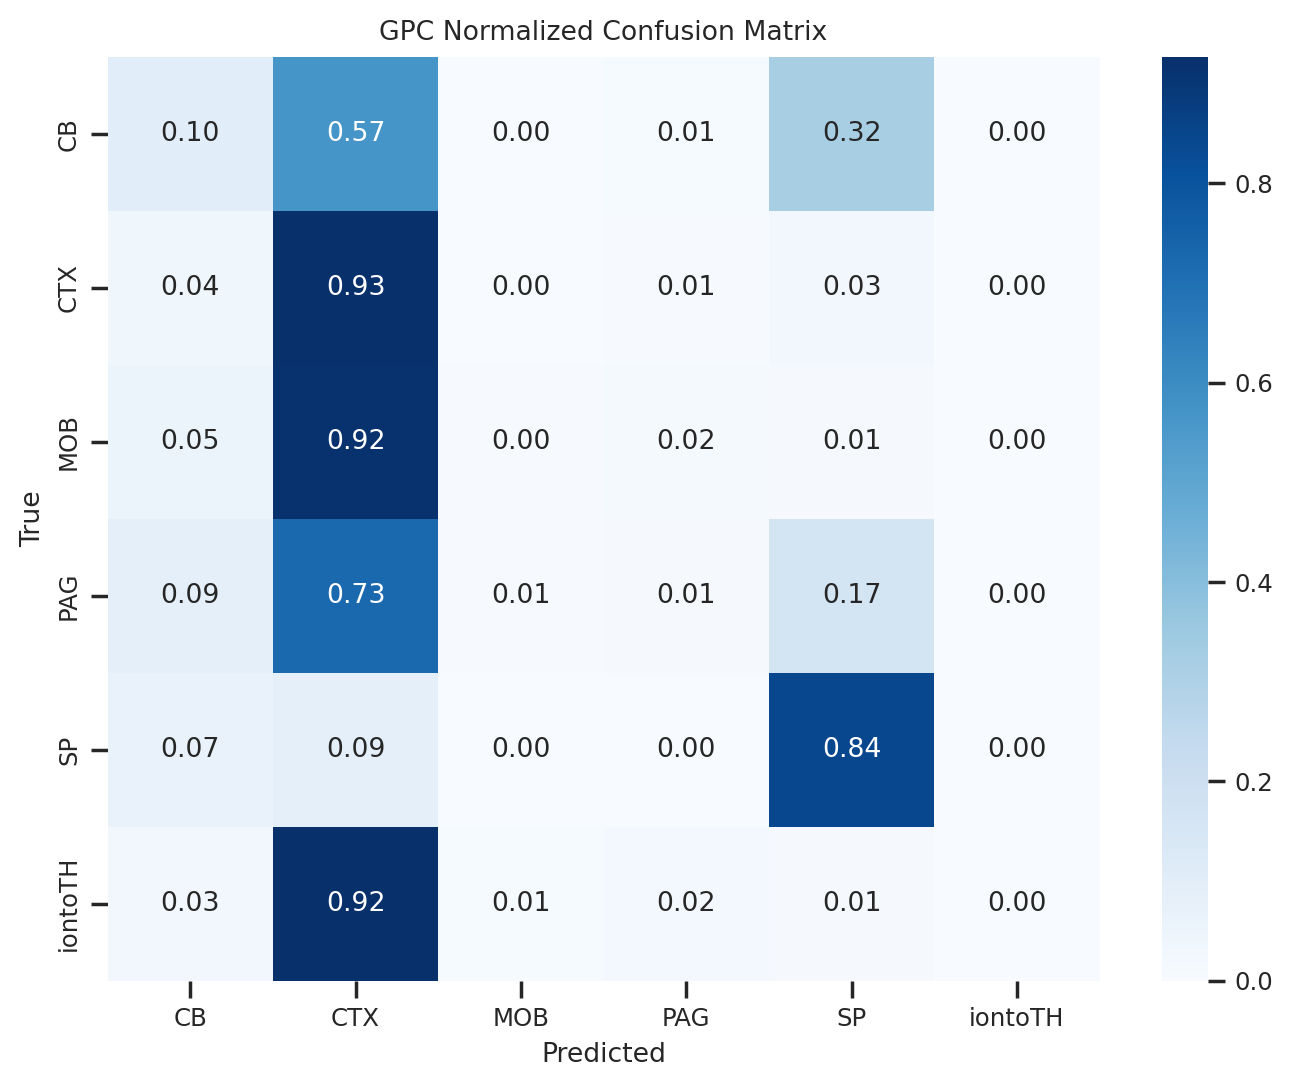

In [20]:
y_true = target
y_pred = y_pred_classes
gpc_labels = list(gp.classes_)

accuracy = accuracy_score(y_true, y_pred)
print(f"GPC Classification Accuracy: {accuracy:.3f}")

report = classification_report(
    y_true, y_pred,
    labels=gpc_labels,
    target_names=gpc_labels,
    digits=3,
    zero_division=0
)
print("GPC Classification Report (F1 scores):\n", report)

print("GPC Mean Posterior Probabilities per Class:")
for class_name, mean_prob in zip(gpc_labels, y_pred_proba.mean(axis=0)):
    print(f"{class_name}: {mean_prob:.4f}")

cm = confusion_matrix(y_true, y_pred, labels=gpc_labels, normalize='true')
print("\nGPC Normalized Confusion Matrix:")
print(pd.DataFrame(cm, index=gpc_labels, columns=gpc_labels))

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=gpc_labels, yticklabels=gpc_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("GPC Normalized Confusion Matrix")
plt.show()